In [1]:
import json
import os
from pathlib import Path
import subprocess
import sys

project_root = Path("/home/petar/GraphProject/GraphProject")
bench_binary = project_root / "build" / "benchmarks" / "run_benchmarks"
output_file = project_root / "build" / "results.json"

if not bench_binary.exists():
    print(f"Benchmark binary not found: {bench_binary}")
else:
    print(f"Found benchmark binary: {bench_binary}")
    print("Running Google Benchmark and saving output to JSON...")

    result = subprocess.run(
        [
            str(bench_binary),
            f"--benchmark_out={output_file}",
            "--benchmark_out_format=json",
        ],
        capture_output=True,
        text=True,
    )

    if result.returncode == 0:
        print(f"Benchmark completed successfully. Results saved to: {output_file}")
    else:
        print("Error executing benchmark:")
        print(result.stderr)

Found benchmark binary: /home/petar/GraphProject/GraphProject/build/benchmarks/run_benchmarks
Running Google Benchmark and saving output to JSON...
Benchmark completed successfully. Results saved to: /home/petar/GraphProject/GraphProject/build/results.json


In [2]:
import json
import os
from pathlib import Path

project_root = Path("/home/petar/GraphProject/GraphProject")
results_path = project_root / "build" / "results.json"

if not results_path.exists():
    raise FileNotFoundError(f"File {results_path} not found. Run Cell 1 first.")

with open(results_path, "r") as f:
    benchmark_data = json.load(f)

traversal_metrics = {
    "NaiveGraph": {"N": [], "time": [], "throughput": []},
    "CSRGraph": {"N": [], "time": [], "throughput": []},
    "CBListGraph": {"N": [], "time": [], "throughput": []},
}

insertion_metrics = {
    "NaiveGraph": {"N": [], "time": [], "throughput": []},
    "CBListGraph": {"N": [], "time": [], "throughput": []},
}

for run in benchmark_data["benchmarks"]:
    name = run["name"]
    vertex_count = int(name.split("/")[-1])
    exec_time_ms = run["real_time"]
    throughput_meps = run.get("items_per_second", 0.0) / 1_000_000.0

    if "BM_Traversal" in name or "BM_NeighborTraversal" in name:
        if "CSR" in name:
            target = traversal_metrics["CSRGraph"]
        elif "CBList" in name:
            target = traversal_metrics["CBListGraph"]
        else:
            target = traversal_metrics["NaiveGraph"]

        target["N"].append(vertex_count)
        target["time"].append(exec_time_ms)
        target["throughput"].append(throughput_meps)

    elif "BM_Insertion" in name or "BM_EdgeInsertion" in name:
        if "CBList" in name:
            target = insertion_metrics["CBListGraph"]
        else:
            target = insertion_metrics["NaiveGraph"]

        target["N"].append(vertex_count)
        target["time"].append(exec_time_ms)
        target["throughput"].append(throughput_meps)

print("Data extracted successfully:")
print(
    f"Naive Traversal points: {len(traversal_metrics['NaiveGraph']['time'])} {traversal_metrics['NaiveGraph']['time']}"
)
print(
    f"CSR Traversal points:   {len(traversal_metrics['CSRGraph']['time'])} {traversal_metrics['CSRGraph']['time']}"
)
print(
    f"CBList Traversal points: {len(traversal_metrics['CBListGraph']['time'])} {traversal_metrics['CBListGraph']['time']}"
)

Data extracted successfully:
Naive Traversal points: 5 [0.047787367688213345, 0.23863330614337083, 2.170671445482556, 20.366394971428495, 44.647735249995435]
CSR Traversal points:   5 [0.040665197148805204, 0.24065913239338282, 1.1770309653462188, 17.882827804874623, 42.397017374995016]
CBList Traversal points: 5 [0.12850439798017807, 0.5881721723260387, 13.80611515686474, 68.49652229998355, 141.0931693999828]


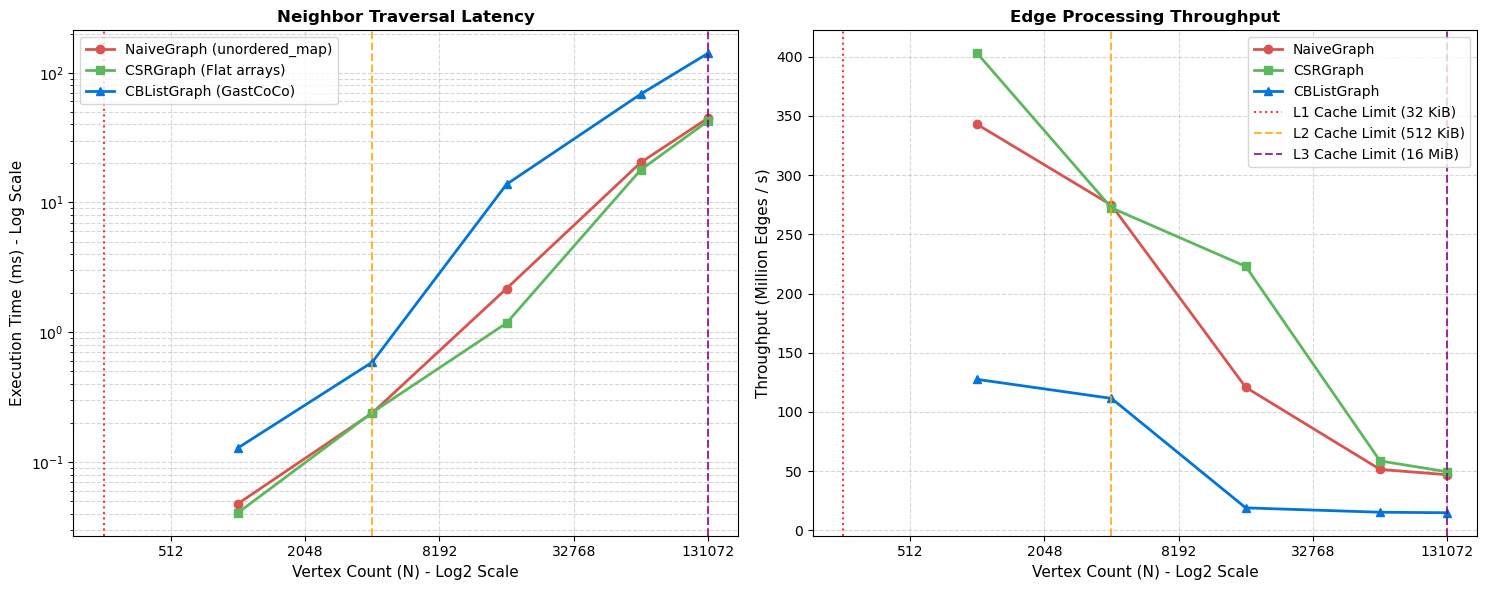

In [3]:
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt

fig, (ax_latency, ax_throughput) = plt.subplots(1, 2, figsize=(15, 6))

# Traversal latency comparison
ax_latency.plot(
    traversal_metrics["NaiveGraph"]["N"],
    traversal_metrics["NaiveGraph"]["time"],
    marker="o",
    markersize=6,
    linestyle="-",
    color="#d9534f",
    label="NaiveGraph (unordered_map)",
    linewidth=2,
)
ax_latency.plot(
    traversal_metrics["CSRGraph"]["N"],
    traversal_metrics["CSRGraph"]["time"],
    marker="s",
    markersize=6,
    linestyle="-",
    color="#5cb85c",
    label="CSRGraph (Flat arrays)",
    linewidth=2,
)
ax_latency.plot(
    traversal_metrics["CBListGraph"]["N"],
    traversal_metrics["CBListGraph"]["time"],
    marker="^",
    markersize=6,
    linestyle="-",
    color="#0275d8",
    label="CBListGraph (GastCoCo)",
    linewidth=2,
)

ax_latency.set_xscale("log", base=2)
ax_latency.set_yscale("log")
ax_latency.set_xlabel("Vertex Count (N) - Log2 Scale", fontsize=11)
ax_latency.set_ylabel("Execution Time (ms) - Log Scale", fontsize=11)
ax_latency.set_title(
    "Neighbor Traversal Latency", fontsize=12, fontweight="bold"
)
ax_latency.grid(True, which="both", ls="--", alpha=0.5)
ax_latency.legend(loc="upper left")

# Edge traversal throughput comparison
ax_throughput.plot(
    traversal_metrics["NaiveGraph"]["N"],
    traversal_metrics["NaiveGraph"]["throughput"],
    marker="o",
    markersize=6,
    linestyle="-",
    color="#d9534f",
    label="NaiveGraph",
    linewidth=2,
)
ax_throughput.plot(
    traversal_metrics["CSRGraph"]["N"],
    traversal_metrics["CSRGraph"]["throughput"],
    marker="s",
    markersize=6,
    linestyle="-",
    color="#5cb85c",
    label="CSRGraph",
    linewidth=2,
)
ax_throughput.plot(
    traversal_metrics["CBListGraph"]["N"],
    traversal_metrics["CBListGraph"]["throughput"],
    marker="^",
    markersize=6,
    linestyle="-",
    color="#0275d8",
    label="CBListGraph",
    linewidth=2,
)

ax_throughput.set_xscale("log", base=2)
ax_throughput.set_xlabel("Vertex Count (N) - Log2 Scale", fontsize=11)
ax_throughput.set_ylabel("Throughput (Million Edges / s)", fontsize=11)
ax_throughput.set_title(
    "Edge Processing Throughput", fontsize=12, fontweight="bold"
)
ax_throughput.grid(True, which="both", ls="--", alpha=0.5)

# CPU cache threshold reference lines (L1 = 32 KiB, L2 = 512 KiB, L3 = 16 MiB)
for axis in (ax_latency, ax_throughput):
    axis.axvline(
        x=256,
        color="red",
        linestyle=":",
        alpha=0.8,
        label="L1 Cache Limit (32 KiB)",
    )
    axis.axvline(
        x=4096,
        color="orange",
        linestyle="--",
        alpha=0.8,
        label="L2 Cache Limit (512 KiB)",
    )
    axis.axvline(
        x=131072,
        color="purple",
        linestyle="--",
        alpha=0.8,
        label="L3 Cache Limit (16 MiB)",
    )
    axis.xaxis.set_major_formatter(ScalarFormatter())

ax_throughput.legend(loc="upper right")
plt.tight_layout()
plt.savefig("traversal_cache_analysis.png", dpi=300)
plt.show()

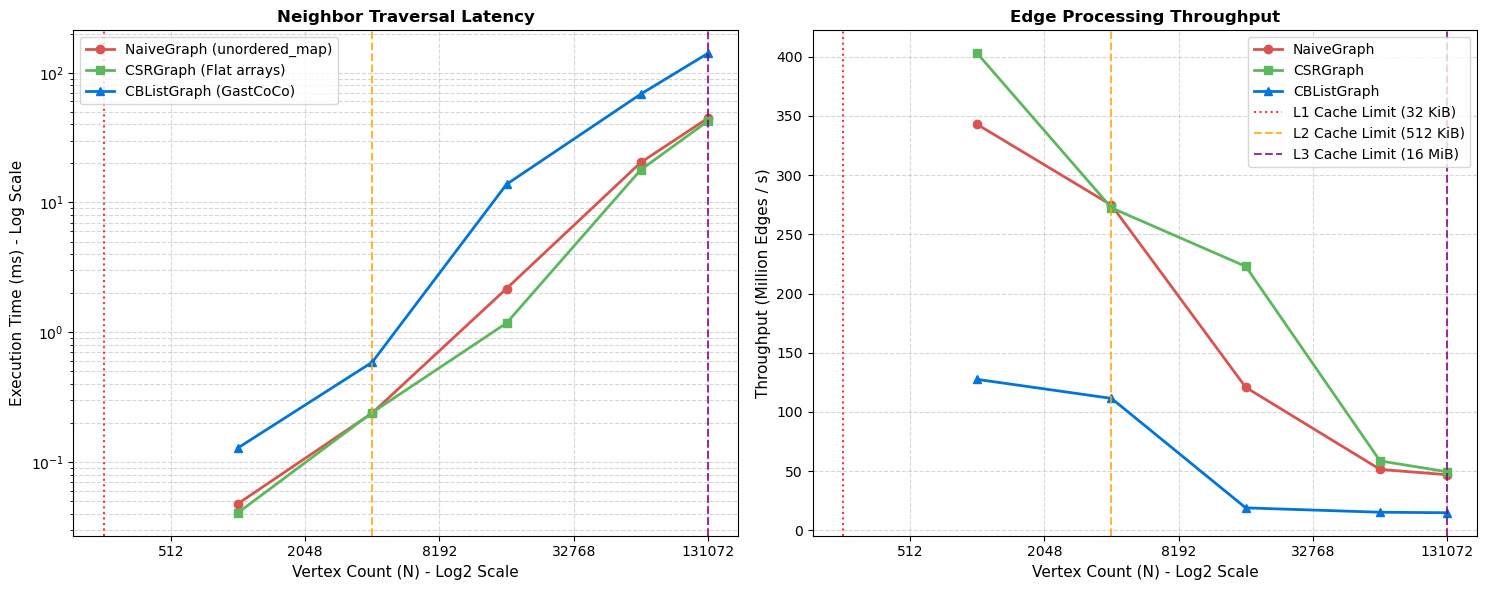

In [4]:
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt

fig, (ax_latency, ax_throughput) = plt.subplots(1, 2, figsize=(15, 6))

# Traversal latency (scan time per run in ms)
ax_latency.plot(
    traversal_metrics["NaiveGraph"]["N"],
    traversal_metrics["NaiveGraph"]["time"],
    marker="o",
    markersize=6,
    linestyle="-",
    color="#d9534f",
    label="NaiveGraph (unordered_map)",
    linewidth=2,
)
ax_latency.plot(
    traversal_metrics["CSRGraph"]["N"],
    traversal_metrics["CSRGraph"]["time"],
    marker="s",
    markersize=6,
    linestyle="-",
    color="#5cb85c",
    label="CSRGraph (Flat arrays)",
    linewidth=2,
)
ax_latency.plot(
    traversal_metrics["CBListGraph"]["N"],
    traversal_metrics["CBListGraph"]["time"],
    marker="^",
    markersize=6,
    linestyle="-",
    color="#0275d8",
    label="CBListGraph (GastCoCo)",
    linewidth=2,
)

ax_latency.set_xscale("log", base=2)
ax_latency.set_yscale("log")
ax_latency.set_xlabel("Vertex Count (N) - Log2 Scale", fontsize=11)
ax_latency.set_ylabel("Execution Time (ms) - Log Scale", fontsize=11)
ax_latency.set_title(
    "Neighbor Traversal Latency", fontsize=12, fontweight="bold"
)
ax_latency.grid(True, which="both", ls="--", alpha=0.5)
ax_latency.legend(loc="upper left")

# Traversal throughput (million edges processed per second)
ax_throughput.plot(
    traversal_metrics["NaiveGraph"]["N"],
    traversal_metrics["NaiveGraph"]["throughput"],
    marker="o",
    markersize=6,
    linestyle="-",
    color="#d9534f",
    label="NaiveGraph",
    linewidth=2,
)
ax_throughput.plot(
    traversal_metrics["CSRGraph"]["N"],
    traversal_metrics["CSRGraph"]["throughput"],
    marker="s",
    markersize=6,
    linestyle="-",
    color="#5cb85c",
    label="CSRGraph",
    linewidth=2,
)
ax_throughput.plot(
    traversal_metrics["CBListGraph"]["N"],
    traversal_metrics["CBListGraph"]["throughput"],
    marker="^",
    markersize=6,
    linestyle="-",
    color="#0275d8",
    label="CBListGraph",
    linewidth=2,
)

ax_throughput.set_xscale("log", base=2)
ax_throughput.set_xlabel("Vertex Count (N) - Log2 Scale", fontsize=11)
ax_throughput.set_ylabel("Throughput (Million Edges / s)", fontsize=11)
ax_throughput.set_title(
    "Edge Processing Throughput", fontsize=12, fontweight="bold"
)
ax_throughput.grid(True, which="both", ls="--", alpha=0.5)

# CPU cache threshold reference lines
for axis in (ax_latency, ax_throughput):
    axis.axvline(
        x=256,
        color="red",
        linestyle=":",
        alpha=0.8,
        label="L1 Cache Limit (32 KiB)",
    )
    axis.axvline(
        x=4096,
        color="orange",
        linestyle="--",
        alpha=0.8,
        label="L2 Cache Limit (512 KiB)",
    )
    axis.axvline(
        x=131072,
        color="purple",
        linestyle="--",
        alpha=0.8,
        label="L3 Cache Limit (16 MiB)",
    )
    axis.xaxis.set_major_formatter(ScalarFormatter())

ax_throughput.legend(loc="upper right")
plt.tight_layout()
plt.savefig("traversal_cache_analysis.png", dpi=300)
plt.show()

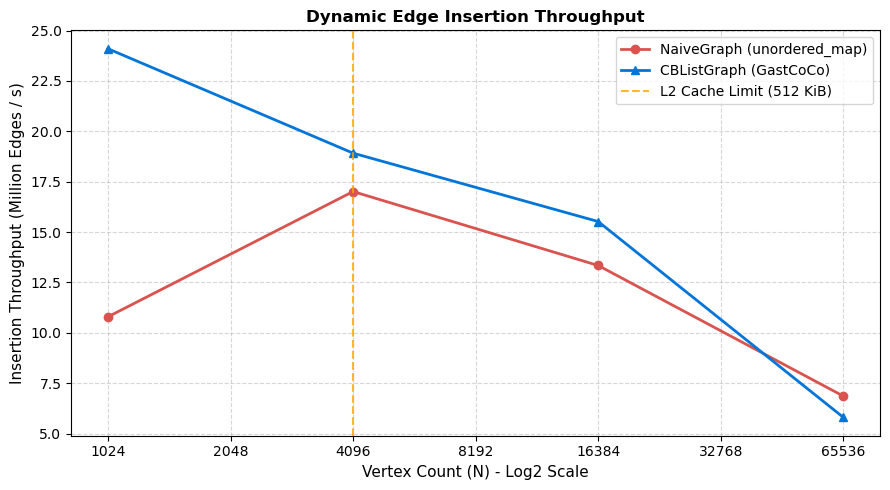

In [5]:
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    insertion_metrics["NaiveGraph"]["N"],
    insertion_metrics["NaiveGraph"]["throughput"],
    marker="o",
    markersize=6,
    linestyle="-",
    color="#d9534f",
    label="NaiveGraph (unordered_map)",
    linewidth=2,
)
plt.plot(
    insertion_metrics["CBListGraph"]["N"],
    insertion_metrics["CBListGraph"]["throughput"],
    marker="^",
    markersize=6,
    linestyle="-",
    color="#0275d8",
    label="CBListGraph (GastCoCo)",
    linewidth=2,
)

plt.xscale("log", base=2)
plt.xlabel("Vertex Count (N) - Log2 Scale", fontsize=11)
plt.ylabel("Insertion Throughput (Million Edges / s)", fontsize=11)
plt.title("Dynamic Edge Insertion Throughput", fontsize=12, fontweight="bold")

plt.axvline(
    x=4096,
    color="orange",
    linestyle="--",
    alpha=0.8,
    label="L2 Cache Limit (512 KiB)",
)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.tight_layout()
plt.savefig("insertion_throughput.png", dpi=300)
plt.show()